In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random
import torch
from torchvision import T as T
import torchvision.T.functional as TF

# For interactive plots in notebooks
%matplotlib inline


c:\Users\Chiara\.conda\envs\iapr_project\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
DATA_DIR = '../dataset_project_iapr2025'

train_dir = os.path.join(DATA_DIR, 'train')
test_dir = os.path.join(DATA_DIR, 'test')
ref_dir = os.path.join(DATA_DIR, 'references')
annotations_path = os.path.join(DATA_DIR, 'train.csv')


In [3]:
annotations_df = pd.read_csv(annotations_path)
annotations_df.head()

,id,Jelly White,Jelly Milk,Jelly Black,Amandina,Crème brulée,Triangolo,Tentation noir,Comtesse,Noblesse,Noir authentique,Passion au lait,Arabia,Stracciatella
0,1000756,2,0,0,0,0,1,0,0,1,0,0,0,2
1,1000763,2,3,3,0,0,0,0,0,0,0,0,0,0
2,1000765,0,0,0,0,0,3,0,0,0,0,2,0,0
3,1000768,0,0,0,0,0,0,0,1,1,0,0,0,2
4,1000772,3,2,1,0,0,0,0,0,0,0,0,0,0


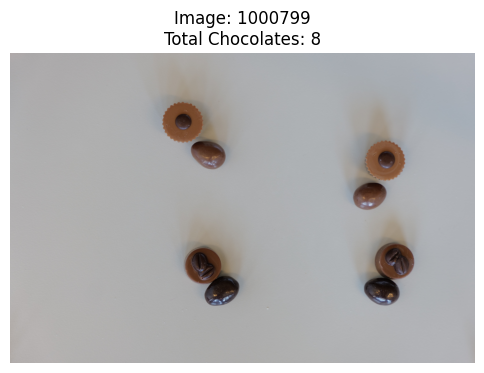

In [4]:
def show_random_train_image():
    row = annotations_df.sample(1).iloc[0]
    img_path = os.path.join(train_dir, "L"+str(row['id'])+".JPG")
    
    img = Image.open(img_path)
    total_chocolates = row.drop('id').sum()
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Image: {row['id']}\nTotal Chocolates: {total_chocolates}")
    plt.axis('off')
    plt.show()

show_random_train_image()


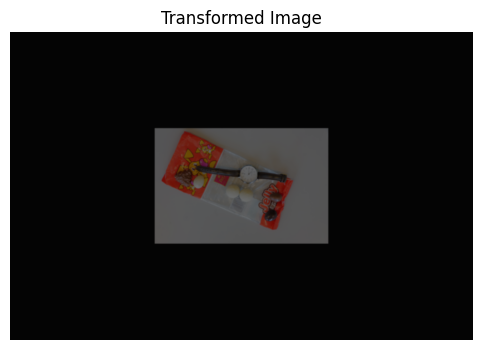

In [14]:
transform = T.Compose([
    T.Resize(512),  # resize shorter side to 512, preserves aspect ratio
    T.CenterCrop((1365, 2048)),  # target crop size (height, width)
    T.ColorJitter(brightness=0.5, contrast=1.0, saturation=0.5),
    T.GaussianBlur(kernel_size=5, sigma=(5.0, 10.0)),  # kernel_size must be odd int or tuple of ints
    T.RandomErasing(p=0.3),  # should be used in tensor space, after ToTensor()
    T.ToTensor()
])

# Load one image
row = annotations_df.sample(1).iloc[0]
img_path = os.path.join(train_dir, "L" + str(row['id']) + ".JPG")
img = Image.open(img_path).convert("RGB")

# Apply transform
tensor_img = transform(img)

# Convert tensor to image for plotting
np_img = tensor_img.permute(1, 2, 0).numpy()

# Plot
plt.figure(figsize=(6, 4))
plt.imshow(np.clip(np_img, 0, 1))
plt.title("Transformed Image")
plt.axis("off")
plt.show()


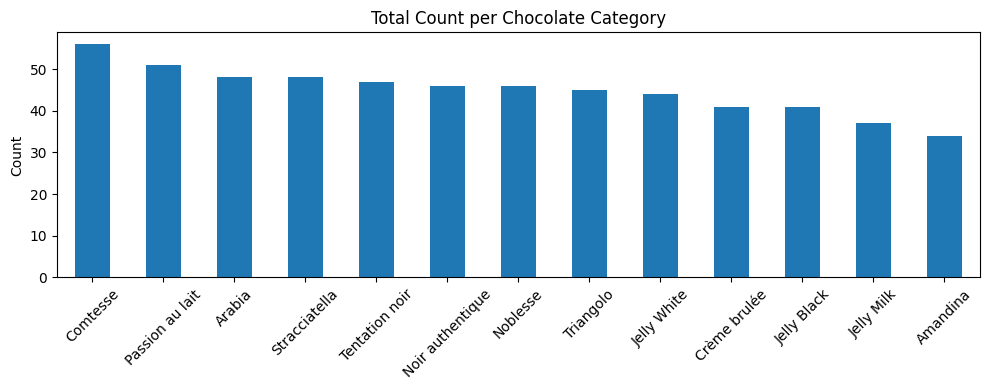

In [8]:
category_cols = [col for col in annotations_df.columns if col not in ['id']]
category_sums = annotations_df[category_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
category_sums.plot(kind='bar')
plt.title('Total Count per Chocolate Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
def show_reference_images(n=5):
    ref_files = os.listdir(ref_dir)
    ref_files = random.sample(ref_files, min(n, len(ref_files)))
    
    plt.figure(figsize=(15, 3))
    for i, fname in enumerate(ref_files):
        img = Image.open(os.path.join(ref_dir, fname))
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(fname.split('.')[0])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_reference_images()


AttributeError: shape

<Figure size 1500x300 with 0 Axes>

In [ ]:
#First trial data augmentation

train_T = T.Compose([
    T.RandomResizedCrop(size=512, scale=(0.9, 1.0)),   # Crop and scale
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=20), 
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

ref_T = T.Compose([
    T.Resize((128, 128)),  # Normalize input shape
    T.RandomRotation(degrees=90),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.ToTensor(),
])

train_files = os.listdir(train_dir)
train_paths = [os.path.join(train_dir, f) for f in train_files if f.lower().endswith(('.jpg'))]

ref_files = os.listdir(ref_dir)
ref_paths = [os.path.join(ref_dir, f) for f in ref_files if f.lower().endswith(('.jpg'))]

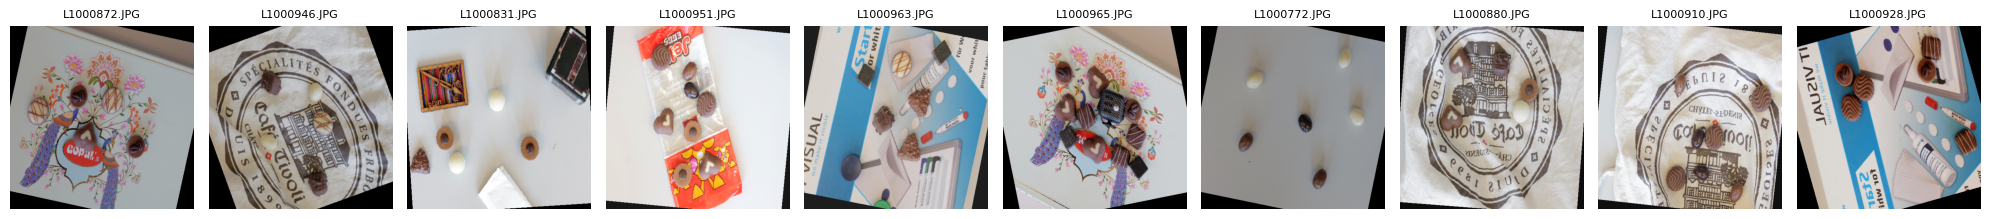

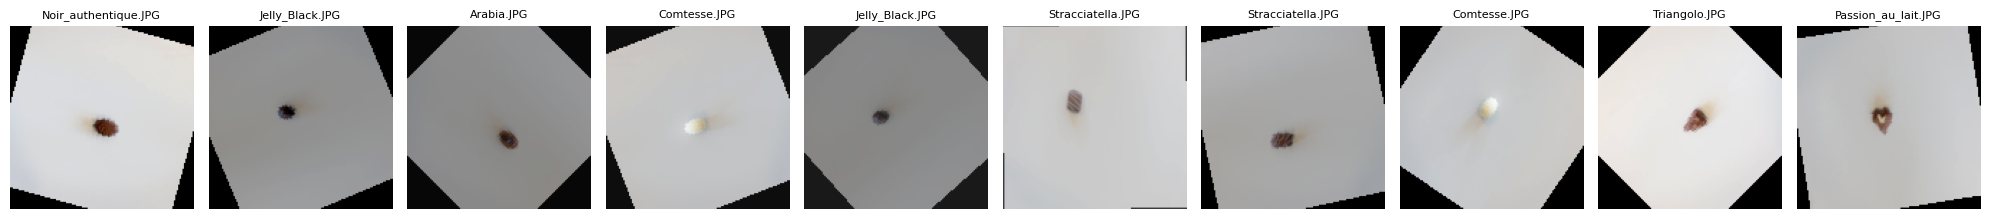

In [ ]:
def show_augmented_images(image_paths, transform, n=10):
    plt.figure(figsize=(n * 2, 4))
    for i in range(n):
        img_path = random.choice(image_paths)
        img = Image.open(img_path).convert("RGB")
        augmented = transform(img)
        plt.subplot(1, n, i + 1)
        plt.imshow(TF.to_pil_image(augmented))
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function
show_augmented_images(train_paths, train_T)
show_augmented_images(ref_paths, ref_T)